# TBFM Multi-session Demo

This notebook walks through the **multisession** TBFM workflow end-to-end:

1. Build procedurally-generated low-D data for several sessions.
2. Pretrain a shared TBFM jointly across those sessions, with per-session learnable embeddings.
3. Save the trained model.
4. Generate **held-out** sessions the model has never seen.
5. Run **test-time adaptation (TTA)** to specialize the trained model to each held-out session using a tiny support set.
6. Evaluate held-out forecasts.

The data here is intentionally tiny and synthetic so the workflow itself is what's on display. The same code paths (`tbfm.multisession.build_from_cfg`, `train_from_cfg`, `test_time_adaptation`, ...) are used in production via `tma_standalone.py`. Real-world setups just feed in real neural data via `tbfm.dataset.SessionLoader`.

In [2]:
%load_ext autoreload
%autoreload 2

import os
import shutil

import matplotlib.pyplot as plt
import torch

from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra

from tbfm import multisession, test

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print("Device:", DEVICE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda:0


## 1. Generate per-session synthetic data

We make several "held-in" training sessions. Each session is an Ornstein–Uhlenbeck process with sinusoidal moving mean, just like `TBFM Demo.ipynb`, but each session gets its own **phase shift and amplitude scale**. That session-specific structure is exactly what the multisession model has to capture via its **per-session learnable stim embeddings**.


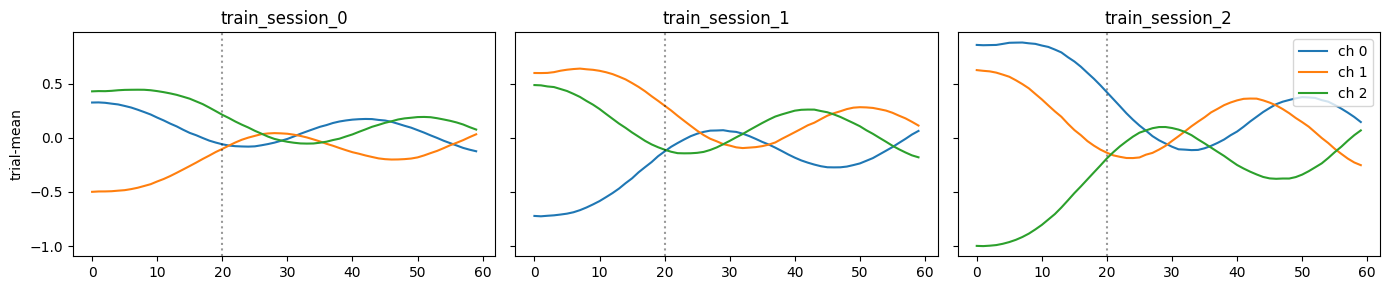

In [3]:
RUNWAY_LENGTH = 20
FORECAST_HORIZON = 40
TRIAL_LENGTH = RUNWAY_LENGTH + FORECAST_HORIZON
NUM_CHANNELS = 3
STIM_DIM = 2  # unpacked covariate dim (cfg.covariate_dim subtracts 1 internally)
TRIALS_PER_SESSION = 3000
TRAIN_TRIALS = 2000
BATCH_SIZE_PER_SESSION = 400

TRAIN_SESSION_IDS = [f"train_session_{i}" for i in range(6)]

train_session_data = test.generate_multisession_demo_data(
    TRAIN_SESSION_IDS,
    trials_per_session=TRIALS_PER_SESSION,
    runway_length=RUNWAY_LENGTH,
    forecast_horizon=FORECAST_HORIZON,
    num_channels=NUM_CHANNELS,
    stimdim=STIM_DIM,
    device=DEVICE,
    seed=0,
)

# Quick look at the per-session trial means: each session looks similar in form
# but with a different phase / wavelength.
num_graphs = min(3, len(TRAIN_SESSION_IDS))
fig, axes = plt.subplots(1, num_graphs, figsize=(14, 3), sharey=True)
for ax, sid in zip(axes, TRAIN_SESSION_IDS[:num_graphs]):
    runway, _, y = train_session_data[sid]
    full = torch.cat([runway, y], dim=1).mean(dim=0).cpu()
    for c in range(NUM_CHANNELS):
        ax.plot(full[:, c], label=f"ch {c}")
    ax.axvline(RUNWAY_LENGTH, color="k", linestyle=":", alpha=0.4)
    ax.set_title(sid)
axes[0].set_ylabel("trial-mean")
axes[-1].legend(loc="upper right")
plt.tight_layout()
plt.show()

Wrap the per-session tensors in a thin `SessionLoader`-compatible class so the production multisession code accepts them without any modification:

In [4]:
data = test.SyntheticMultisessionData(
    train_session_data,
    batch_size_per_session=BATCH_SIZE_PER_SESSION,
)

data_train, data_test = data.train_test_split(TRAIN_TRIALS)

print("Train sessions:", data_train.session_ids)
print("Train trials/session:", data_train.get_session_num_feats(TRAIN_SESSION_IDS[0]))
first_batch = next(iter(data_train))
print("Batch keys:", list(first_batch.keys()))
print("Per-session shapes (runway, stiminds, y):",
      [tuple(t.shape) for t in first_batch[TRAIN_SESSION_IDS[0]]])

Train sessions: ['train_session_0', 'train_session_1', 'train_session_2', 'train_session_3', 'train_session_4', 'train_session_5']
Train trials/session: 3
Batch keys: ['train_session_0', 'train_session_1', 'train_session_2', 'train_session_3', 'train_session_4', 'train_session_5']
Per-session shapes (runway, stiminds, y): [(400, 20, 3), (400, 2), (400, 40, 3)]


## 2. Load and override the production Hydra config

We use the same `conf/` directory `tma_standalone.py` uses, but override a handful of fields to scale things down for this demo (small latent dim, fewer epochs, small batch sizes, no outlier filtering). Everything else stays at production defaults.

In [5]:
GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=os.path.abspath("conf"), version_base=None):
    cfg = compose(
        config_name="config",
        overrides=[
            # Sizes
            f"latent_dim={NUM_CHANNELS}",
            f"covariate_dim={STIM_DIM + 1}",  # production wart: bases drop 1 dim
            f"data.runway={RUNWAY_LENGTH}",
            f"data.y_len={FORECAST_HORIZON}",
            f"data.trial_len={TRIAL_LENGTH}",
            # Training schedule
            "training.epochs=1200",
            "training.test_interval=50",
            "training.use_outlier_filtering=false",
            "training.bw_steps_per_bg_step=1",
            "training.grad_clip=2.0",
            # TBFM module
            "tbfm.module.num_bases=20",
            "tbfm.module.latent_dim=6",
            "tbfm.module.basis_depth=2",
            "tbfm.module.basis_gen_dropout=0.0",
            "tbfm.module.embed_dim_rest=3",
            "tbfm.module.embed_dim_stim=5",
            "tbfm.training.lambda_fro=5.0",
            # Meta-learning
            "meta.basis_residual_rank=5",
            "meta.residual_mlp_hidden=6",
            # support_size MUST be < BATCH_SIZE_PER_SESSION so the outer-loop
            # query set is non-empty. support+query both come from the same batch.
            "meta.training.support_size=200",
            "meta.training.inner_steps=10",
            # AE (small, identity-ish for this low-D demo)
            "ae.training.lambda_ae_recon=0.1",
            "ae.training.ae_freeze_epoch=1000",
        ],
    )
print("latent_dim:", cfg.latent_dim, "num_bases:", cfg.tbfm.module.num_bases)
print(f"support_size: {cfg.meta.training.support_size}  "
      f"batch_size: {BATCH_SIZE_PER_SESSION}  "
      f"query_size: {BATCH_SIZE_PER_SESSION - cfg.meta.training.support_size}")


latent_dim: 3 num_bases: 20
support_size: 200  batch_size: 400  query_size: 200


## 3. Build the multisession model

`build_from_cfg` instantiates one TBFM (shared across sessions), one autoencoder per session, and one normalizer per session, all from the cfg. The training data is used for the AE's PCA warm-start and for fitting the normalizers.

In [6]:
ms = multisession.build_from_cfg(cfg, data_train, device=DEVICE)
print("Sessions in model:", list(ms.model.instances.keys()))

Building and fitting normalizers...
Building and warm starting AEs...
Building TBFM...
BOOM! Dino DNA!
Sessions in model: ['train_session_0', 'train_session_1', 'train_session_2', 'train_session_3', 'train_session_4', 'train_session_5']


## 4. Provide rest embeddings

In production these come from `meta.cache_rest_embeds` (computed once over per-session resting-state activity). Here we just hand it a random fixed embedding per session — the model still has the per-session learnable `embeddings_stim` to specialize via MAML.

In [7]:
embed_dim_rest = cfg.tbfm.module.embed_dim_rest

# Zero rest embeddings for all sessions — deliberately.
# If these were random per-session, the basis generator MLP would learn to
# memorize "session X has embedding Y → use these bases", which does not
# transfer to unseen sessions at TTA. With zero rest embeddings the MLP
# produces one shared canonical basis for all sessions; all session-specific
# adaptation at TTA time is carried by:
#   • embedding_stim  (MAML-adapted on the support set)
#   • the per-session AE  (re-fit from scratch on the support set)
#   • basis_weighting  (reads the encoded runway at inference — no adaptation needed)
embeddings_rest = {
    sid: torch.zeros(embed_dim_rest, device=DEVICE)
    for sid in data_train.session_ids
}
embeddings_rest


{'train_session_0': tensor([0., 0., 0.], device='cuda:0'),
 'train_session_1': tensor([0., 0., 0.], device='cuda:0'),
 'train_session_2': tensor([0., 0., 0.], device='cuda:0'),
 'train_session_3': tensor([0., 0., 0.], device='cuda:0'),
 'train_session_4': tensor([0., 0., 0.], device='cuda:0'),
 'train_session_5': tensor([0., 0., 0.], device='cuda:0')}

## 5. Pretrain

`train_from_cfg` runs the full multisession training loop:
* MAML-style inner loop adapts a per-session `embedding_stim` on a support set each epoch.
* Outer loop updates the shared TBFM weights on the query set.
* Alternating updates between the basis-weighting head and the basis-generator MLP.
* Periodic eval against the held-out trials of each training session.

In [8]:
model_optims = multisession.get_optims(cfg, ms)

embeddings_stim_trained, results = multisession.train_from_cfg(
    cfg,
    ms,
    data_train,
    model_optims,
    embeddings_rest,
    data_test=data_test,
    epochs=cfg.training.epochs,
    support_size=cfg.meta.training.support_size,
    device=DEVICE,
)

print(f"\nFinal test R^2: {results['final_test_r2']:.3f}")
for sid, r2 in results["final_test_r2s"].items():
    print(f"  {sid}: R^2 = {r2:.3f}")

---- 0 0.6959095001220703 0.6944339573383331 -0.42019736270109814 -0.4285577982664108
---- 50 0.4179608225822449 0.4223983436822891 0.14093811064958572 0.12997320294380188
---- 100 0.3897266387939453 0.40312331914901733 0.17436440785725912 0.16865729540586472
---- 150 0.39693117141723633 0.3837038725614548 0.18440562238295874 0.20844079554080963
---- 200 0.3639478087425232 0.37485644221305847 0.2447705939412117 0.23433829843997955
---- 250 0.35767504572868347 0.36357858777046204 0.2595520168542862 0.25167497247457504
---- 300 0.3445838391780853 0.3539855033159256 0.284530205031236 0.2685592472553253
---- 350 0.34748953580856323 0.3451896458864212 0.2835315962632497 0.2872072756290436
---- 400 0.33735987544059753 0.3406360298395157 0.3128483047087987 0.3016709238290787
---- 450 0.33730101585388184 0.3367614448070526 0.3074223150809606 0.30510924756526947
---- 500 0.337766170501709 0.334767609834671 0.31375640134016675 0.31076154112815857
---- 550 0.3311816155910492 0.3312239795923233 0.

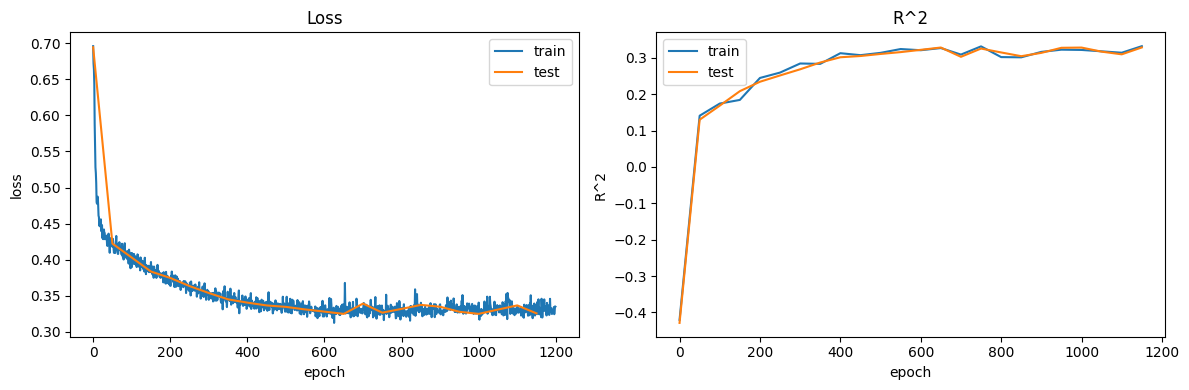

In [9]:
# Loss curves.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tr = results["train_losses"]
te = results["test_losses"]
if tr:
    axes[0].plot([t[0] for t in tr], [t[1] for t in tr], label="train")
if te:
    axes[0].plot([t[0] for t in te], [t[1] for t in te], label="test")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].set_title("Loss")

tr_r2 = results["train_r2s"]
te_r2 = results["test_r2s"]
if tr_r2:
    axes[1].plot([t[0] for t in tr_r2], [t[1] for t in tr_r2], label="train")
if te_r2:
    axes[1].plot([t[0] for t in te_r2], [t[1] for t in te_r2], label="test")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("R^2"); axes[1].legend(); axes[1].set_title("R^2")
plt.tight_layout(); plt.show()

Compare predicted vs. ground-truth channel means on the test set for each training session:

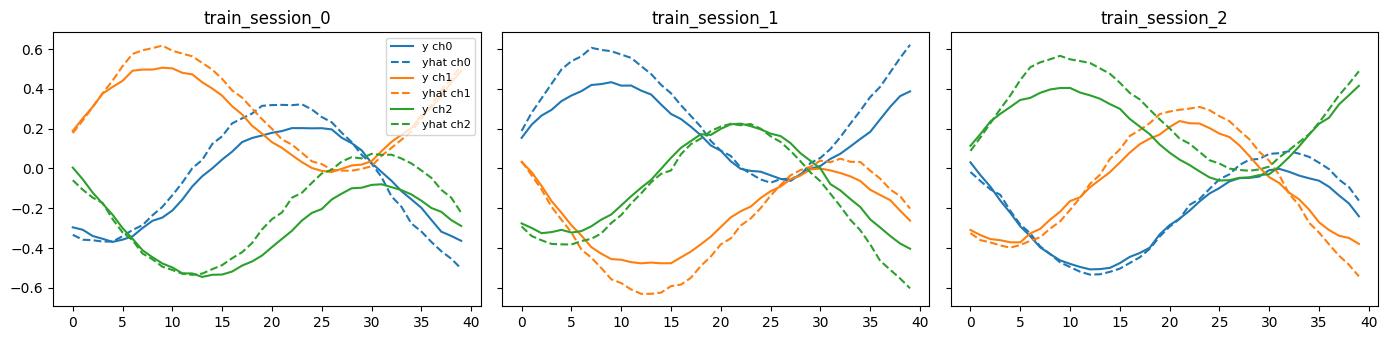

In [10]:
y_test = results["y_test"]
y_hat_test = results["y_hat_test"]

num_graphs = min(3, len(TRAIN_SESSION_IDS))
fig, axes = plt.subplots(1, num_graphs, figsize=(14, 3.5), sharey=True)
for ax, sid in zip(axes, TRAIN_SESSION_IDS[:num_graphs]):
    y = y_test[sid][2].mean(dim=0).cpu()
    yhat = y_hat_test[sid].mean(dim=0).cpu()
    for c in range(NUM_CHANNELS):
        ax.plot(y[:, c], color=f"C{c}", label=f"y ch{c}" if ax is axes[0] else None)
        ax.plot(yhat[:, c], "--", color=f"C{c}", label=f"yhat ch{c}" if ax is axes[0] else None)
    ax.set_title(sid)
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## 6. Save the trained model

`save_model` writes `tbfm.torch`, `ae.torch`, and `norms.torch` to a directory. For TTA we'll reload just the **shared TBFM weights** — the per-session AE and normalizer must be re-fit fresh on each held-out session.

In [17]:
MODEL_DIR = "demo_run"
if os.path.isdir(MODEL_DIR):
    shutil.rmtree(MODEL_DIR)
multisession.save_model(ms, MODEL_DIR)
print("Saved:", os.listdir(MODEL_DIR))

Saved: ['tbfm.torch', 'ae.torch', 'norms.torch']


## 7. Generate held-out sessions

These are new sessions the model has never seen. Their wavelength/phase parameters differ from any training session, so the trained per-session embeddings won't apply directly.

In [24]:
HELDOUT_SESSION_IDS = [f"heldout_session_{i}" for i in range(2)]
HELDOUT_TRIALS = 1200
HELDOUT_SUPPORT = 800

heldout_session_data = test.generate_multisession_demo_data(
    HELDOUT_SESSION_IDS,
    trials_per_session=HELDOUT_TRIALS,
    runway_length=RUNWAY_LENGTH,
    forecast_horizon=FORECAST_HORIZON,
    num_channels=NUM_CHANNELS,
    stimdim=STIM_DIM,
    device=DEVICE,
    scale_max=4.0,      # held-out sessions have larger amplitude than training ones
    seed=100,           # different seed → different sessions
)

heldout_data = test.SyntheticMultisessionData(
    heldout_session_data,
    batch_size_per_session=BATCH_SIZE_PER_SESSION,
)
heldout_train, heldout_test = heldout_data.train_test_split(HELDOUT_SUPPORT)
print("Held-out sessions:", heldout_train.session_ids)

Held-out sessions: ['heldout_session_0', 'heldout_session_1']


## 8. Test-time adaptation on held-out sessions

`test_time_adaptation(joint=True)` keeps the shared TBFM weights frozen and co-adapts:
* Fresh per-session **normalizers** (refit from the support set).
* Fresh per-session **autoencoders** (PCA warm-start, then gradient refinement).
* A per-session **`embedding_stim`** (persistent across steps — never re-initialized).

At each step: `emb_steps_per_ae_step` embedding gradient steps (AE fixed) → one AE gradient step (embeddings detached). Both optimizers carry momentum across all steps so neither component is ever reset to noise. The shared TBFM is never modified.


In [ ]:
TTA_EPOCHS = 7000
TTA_SUPPORT_SIZE = 300
TTA_EMB_STEPS_PER_AE_STEP = 10

# Rebuild a fresh TTA model so joint TTA starts from a clean PCA-warm-started AE.
ms_tta = multisession.build_from_cfg(
    cfg,
    heldout_train,
    base_model_path=os.path.join(MODEL_DIR, "tbfm.torch"),
    device=DEVICE,
)
embeddings_rest_heldout = {
    sid: torch.zeros(embed_dim_rest, device=DEVICE)
    for sid in heldout_train.session_ids
}

embeddings_stim_heldout, tta_results = multisession.test_time_adaptation(
    cfg,
    ms_tta,
    embeddings_rest_heldout,
    heldout_train,
    epochs=TTA_EPOCHS,
    emb_steps_per_ae_step=TTA_EMB_STEPS_PER_AE_STEP,
    data_test=heldout_test,
    ae_warm_start=True,
    support_size=TTA_SUPPORT_SIZE,
    quiet=False,
    joint=True,
)

print(f"\nHeld-out final test R^2: {tta_results['final_test_r2']:.3f}")
for sid, r2 in tta_results.get("final_test_r2s", {}).items():
    print(f"  {sid}: R^2 = {r2:.3f}")
print(f"\nHeld-in training test R^2 for reference:")
for sid, r2 in results["final_test_r2s"].items():
    print(f"  {sid}: R^2 = {r2:.3f}")


Building and fitting normalizers...
Building and warm starting AEs...
Loading base TBFM from file...
BOOM! Dino DNA!
TTA: Using 300 samples for adaptation (support set)
TTA: Refitting normalizers from support set...
TTA: Warm starting autoencoder...
  Warm started AE for heldout_session_0
  Warm started AE for heldout_session_1
TTA: Co-adapting for 7000 steps (10 emb steps per AE step)...
  step 0/7000  loss=0.378277  emb_loss=0.377636
  step 100/7000  loss=0.368942  emb_loss=0.369163
  step 200/7000  loss=0.365838  emb_loss=0.366111
  step 300/7000  loss=0.363477  emb_loss=0.363586
  step 400/7000  loss=0.361371  emb_loss=0.361305
  step 500/7000  loss=0.359435  emb_loss=0.359205
  step 600/7000  loss=0.357641  emb_loss=0.357257
  step 700/7000  loss=0.355966  emb_loss=0.355436
  step 800/7000  loss=0.354400  emb_loss=0.353730
  step 900/7000  loss=0.352930  emb_loss=0.352125
  step 1000/7000  loss=0.351549  emb_loss=0.350613
  step 1100/7000  loss=0.350250  emb_loss=0.349187


## 10. Visualise held-out predictions

Mean predicted vs. groundtruth trajectories on each held-out session's test set:

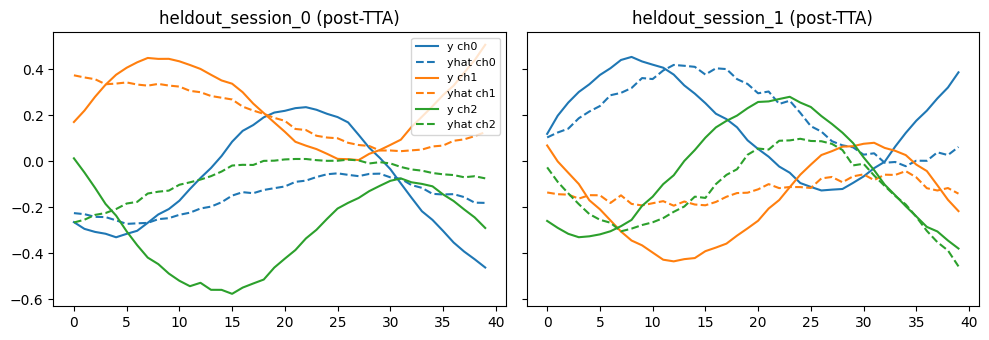

In [22]:
y_heldout = tta_results["y_test"]
y_hat_heldout = tta_results["y_hat_test"]

fig, axes = plt.subplots(1, len(HELDOUT_SESSION_IDS), figsize=(10, 3.5), sharey=True)
if len(HELDOUT_SESSION_IDS) == 1:
    axes = [axes]
for ax, sid in zip(axes, HELDOUT_SESSION_IDS):
    y = y_heldout[sid][2].mean(dim=0).cpu()
    yhat = y_hat_heldout[sid].mean(dim=0).cpu()
    for c in range(NUM_CHANNELS):
        ax.plot(y[:, c], color=f"C{c}", label=f"y ch{c}" if ax is axes[0] else None)
        ax.plot(yhat[:, c], "--", color=f"C{c}", label=f"yhat ch{c}" if ax is axes[0] else None)
    ax.set_title(f"{sid} (post-TTA)")
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## Recap

End-to-end multisession workflow using only the production multisession API:

| Step | API call |
|------|----------|
| Build model from cfg + data | `multisession.build_from_cfg(cfg, data, device=...)` |
| Build optimizers | `multisession.get_optims(cfg, ms)` |
| Pretrain across sessions | `multisession.train_from_cfg(cfg, ms, data_train, model_optims, embeddings_rest, ...)` |
| Save trained TBFM | `multisession.save_model(ms, path)` |
| Adapt to new session (joint TTA) | `multisession.test_time_adaptation(cfg, ms_tta, embeddings_rest, heldout_data, ..., joint=True)` |

`test_time_adaptation(joint=True)` co-adapts the per-session AE and stim embedding jointly with persistent optimizers. Pass `joint=False` (the default) for inner-outer MAML-style TTA.

In a real experiment, swap `test.SyntheticMultisessionData` for `tbfm.dataset.load_data_some_sessions` or `multisession.load_stim_batched` and the rest of the code is unchanged.
